## Visualising interactive maps
This notebook is a simple guide on how to visualize raster images using the **leafmap** and **localtileserver** libraries in combination with **jupyter-server-proxy**.

Using these packages locally is quite easy; however, in a JupyterHub environment, raster visualisation libraries typically need **jupyter-server-proxy** to function.

To help users configure these packages using environment variables, this notebook was created.

In this notebook, we will use these two raster files as examples:

In [2]:
# For this notebook, we will use the following rasters:
product_path_1 = "/data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2025/02/19/S1A_S1A_Coherence_20250207T054220_20250219T054219_DSC_139_V110/S1A_S1A_Coherence_20250207T054220_20250219T054219_DSC_139_V110_VV.tif"
product_path_2 = "/data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2025/02/19/S1A_S1A_Coherence_20250207T054310_20250219T054309_DSC_139_V110/S1A_S1A_Coherence_20250207T054310_20250219T054309_DSC_139_V110_VV.tif"

import os.path
if os.path.exists(product_path_1):
	print(f"The file {product_path_1} exists.")
if os.path.exists(product_path_2):
	print(f"The file {product_path_2} exists.")

The file /data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2025/02/19/S1A_S1A_Coherence_20250207T054220_20250219T054219_DSC_139_V110/S1A_S1A_Coherence_20250207T054220_20250219T054219_DSC_139_V110_VV.tif exists.
The file /data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2025/02/19/S1A_S1A_Coherence_20250207T054310_20250219T054309_DSC_139_V110/S1A_S1A_Coherence_20250207T054310_20250219T054309_DSC_139_V110_VV.tif exists.


### Localtileserver
The localtileserver allows users to create a backend tileserver that converts local raster data (e.g. GeoTIFFs) into web map tiles (XYZ tiles) so they can be displayed interactively in a web map or notebook. We can use the tileserver in combination with the ipyleaflet library to visualise rasters. Here is an example on how to run this package.

In [3]:
from localtileserver import TileClient
import os

# Update LOCALTILESERVER_CLIENT_PREFIX to handle the JUPYTERHUB_SERVICE_PREFIX. If this is running locally, you can comment out these lines.
if os.environ.get('JUPYTERHUB_SERVICE_PREFIX') and 'LOCALTILESERVER_CLIENT_PREFIX' not in os.environ:
    os.environ['LOCALTILESERVER_CLIENT_PREFIX'] = f"{os.environ['JUPYTERHUB_SERVICE_PREFIX']}proxy/{{port}}"

# After which, you can create a tile server from local raster file
tile_client_1 = TileClient(product_path_1)

Now we have create a tile server for each raster file, which serves the raster data as web map tiles. These tiles can be retrieved individually, in the code below we can fetch the middle tile on zoom level 8.

z: 8 x: 133 y: 85


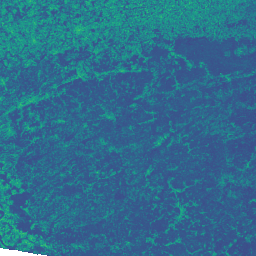

In [4]:
import mercantile

zoom = 8  # any value in [6, 12]
ymin, ymax, xmin, xmax = tile_client_1.bounds(projection="EPSG:4326")
center_lon = (xmin + xmax) / 2
center_lat = (ymin + ymax) / 2
t = mercantile.tile(center_lon, center_lat, zoom)
print("z:",t.z, "x:", t.x,"y:", t.y)
img = tile_client_1.tile(t.z, t.x, t.y, colormap="viridis")
img

Instead of the tiles individually, we can also get a sneak peak at the entire raster by fetching a preview image. The preview image is a downsampled version of the original raster, which can be used to quickly visualize the raster without loading the entire dataset.

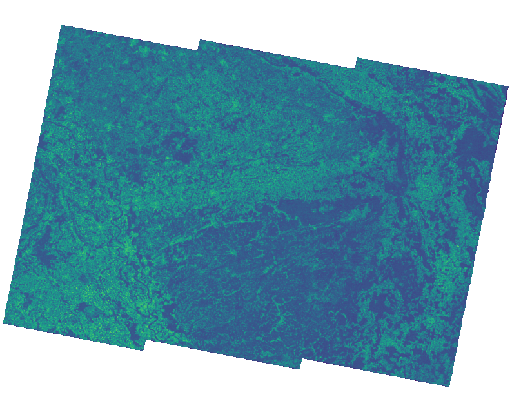

In [5]:
tile_client_1.thumbnail(colormap="viridis")

This might be very cool, however it is not very interactive. To make it more interactive, we can use the ipyleaflet library to create an interactive map and add the raster as a layer. The ipyleaflet library is a Jupyter widget that allows us to create interactive maps in Jupyter notebooks. Here is an example on how to do this.

In [10]:
from localtileserver import get_leaflet_tile_layer
from ipyleaflet import Map, FullScreenControl

# Create the layers using the tileservers
layer1 = get_leaflet_tile_layer(tile_client_1, colormap="viridis")

# Create the map and add the layers
m = Map(center=tile_client_1.center(), zoom=4.5)
m.add(layer1)

# Visualise
m

Map(center=[51.442992, 7.78762], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

It is also possible to add multiple layers to one map, for example, we can add all VH bands from the same day to the map. Here is an example on how to do this.

In [13]:
import glob as glob_module
from pathlib import Path

map_day = Map(center=tile_client_1.center(), zoom=4.5)

files = glob_module.glob("/data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2025/02/19/*/*_VH.tif")
for f in sorted(files):
    client = TileClient(f)
    layer = get_leaflet_tile_layer(client, colormap="viridis")
    map_day.add(layer)
    print("Added: ", Path(f).name)

map_day

Added:  S1A_S1A_Coherence_20250207T054220_20250219T054219_DSC_139_V110_VH.tif
Added:  S1A_S1A_Coherence_20250207T054245_20250219T054244_DSC_139_V110_VH.tif
Added:  S1A_S1A_Coherence_20250207T054310_20250219T054309_DSC_139_V110_VH.tif


Map(center=[51.442992, 7.78762], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

This is a brief overview of what you can create using the localtileserver and ipyleaflet libraries. More detailed examples and guides for both guides can be found here:
1. [localtileserver](https://localtileserver.banesullivan.com/index.html)
2. [ipyleaflet](https://ipyleaflet.readthedocs.io/en/latest/index.html)

### Leafmap
Similarly to localtileserver, Leafmap is a package used to create interactive maps with minimal coding. It is built on several open-source libraries such as folium and ipyleaflet, which make it easy to generate interactive visualizations. Below is a code snippet that demonstrates how to create a visualizations containing all VH bands of one day.

Leafmap appends an extra '/' to the end of the JUPYTERHUB_SERVICE_PREFIX. However, by default, JUPYTERHUB_SERVICE_PREFIX already ends with a '/'. This duplication can cause rendering issues, which can be resolved by **temporarily** removing the trailing '/' from the prefix.

In [15]:
import os
import leafmap.leafmap as leafmap

if os.environ.get('JUPYTERHUB_SERVICE_PREFIX'):
    os.environ['JUPYTERHUB_SERVICE_PREFIX'] = os.environ['JUPYTERHUB_SERVICE_PREFIX'][:-1] if os.environ['JUPYTERHUB_SERVICE_PREFIX'][-1] == "/" else os.environ['JUPYTERHUB_SERVICE_PREFIX']

m = leafmap.Map()
files = glob_module.glob("/data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2025/02/19/*/*_VH.tif")
for f in sorted(files):
    m.add_raster(f, colormap="viridis")
    print("Added: ", Path(f).name)

m

Added:  S1A_S1A_Coherence_20250207T054220_20250219T054219_DSC_139_V110_VH.tif
Added:  S1A_S1A_Coherence_20250207T054245_20250219T054244_DSC_139_V110_VH.tif
Added:  S1A_S1A_Coherence_20250207T054310_20250219T054309_DSC_139_V110_VH.tif


Map(center=[48.4472805, 6.938029500000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

When you are done with your render, add the '/' back at the end of the prefix.

In [ ]:
if os.environ.get('JUPYTERHUB_SERVICE_PREFIX'):
    os.environ['JUPYTERHUB_SERVICE_PREFIX'] = os.environ['JUPYTERHUB_SERVICE_PREFIX'] if os.environ['JUPYTERHUB_SERVICE_PREFIX'][-1] == "/" else f"{os.environ['JUPYTERHUB_SERVICE_PREFIX']}/"